## Data collection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
%matplotlib inline

In [3]:
df=pd.read_csv(r"C:\Users\hp\Downloads\bengaluru_house_prices.csv")
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


## Exploratory data Analysis

In [5]:
df.shape

(13320, 9)

In [6]:
df.size

119880

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [8]:
pd.crosstab(df["bath"],df["balcony"])

balcony,0.0,1.0,2.0,3.0
bath,,,,
1.0,217,522,43,4
2.0,413,3196,2720,505
3.0,166,730,1598,652
4.0,116,278,446,268
5.0,51,105,170,104
6.0,35,43,91,75
7.0,13,10,27,32
8.0,7,8,12,15
9.0,4,5,5,13


In [9]:
pd.crosstab(df["society"],df["balcony"])

balcony,0.0,1.0,2.0,3.0
society,,,,
3Codeli,0,0,2,0
7 ise P,0,1,0,0
A idse,0,0,2,0
A rtsai,0,1,0,0
ACersd,0,0,1,0
...,...,...,...,...
Zonce E,0,0,2,0
Zostaa,0,3,0,0
i1ncyRe,0,0,1,0


In [10]:
df["society"].value_counts()

society
GrrvaGr    80
PrarePa    76
Sryalan    59
Prtates    59
GMown E    56
           ..
Maa 5a      1
AeisePV     1
SJovest     1
ThhtsV      1
RSntsAp     1
Name: count, Length: 2688, dtype: int64

In [11]:
df["availability"].value_counts()

availability
Ready To Move    10581
18-Dec             307
18-May             295
18-Apr             271
18-Aug             200
                 ...  
15-Aug               1
17-Jan               1
16-Nov               1
16-Jan               1
14-Jul               1
Name: count, Length: 81, dtype: int64

## Graphs

In [ ]:
sns.countplot(data=df,x="price")            
plt.show()

In [ ]:
sns.countplot(data=df,x="balcony")           
plt.show()

In [ ]:
sns.countplot(data=df,x="bath")           
plt.show()

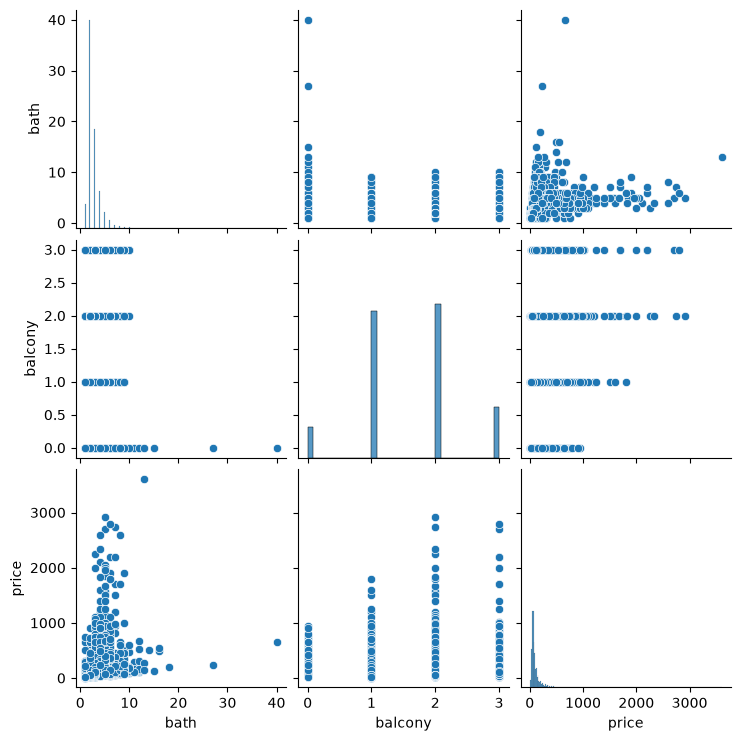

In [16]:
sns.pairplot(df)
plt.show()

In [17]:
df.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


## Data Cleaning

In [19]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [20]:
df['society'].mode()

0    GrrvaGr
Name: society, dtype: str

In [21]:
df['society']=df['society'].fillna("GrrvaGr")

In [22]:
df.isnull().sum()

area_type         0
availability      0
location          1
size             16
society           0
total_sqft        0
bath             73
balcony         609
price             0
dtype: int64

In [23]:
df1=df.dropna()


In [24]:
df1.isnull().sum()

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

## Encoding

In [26]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1["area_type"]=le.fit_transform(df1["area_type"])
df1

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,3,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,2,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,0,Ready To Move,Uttarahalli,3 BHK,GrrvaGr,1440,2.0,3.0,62.00
3,3,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,3,Ready To Move,Kothanur,2 BHK,GrrvaGr,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13314,3,Ready To Move,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,0,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13317,0,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,3,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [27]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1["availability"]=le.fit_transform(df1["availability"])
df1

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,3,38,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,2,77,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,0,77,Uttarahalli,3 BHK,GrrvaGr,1440,2.0,3.0,62.00
3,3,77,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,3,77,Kothanur,2 BHK,GrrvaGr,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13314,3,77,Green Glen Layout,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,0,77,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13317,0,77,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,3,30,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [28]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1["location"]=le.fit_transform(df1["location"])
df1

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,3,38,407,2 BHK,Coomee,1056,2.0,1.0,39.07
1,2,77,306,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,0,77,1141,3 BHK,GrrvaGr,1440,2.0,3.0,62.00
3,3,77,738,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,3,77,697,2 BHK,GrrvaGr,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13314,3,77,462,3 BHK,SoosePr,1715,3.0,3.0,112.00
13315,0,77,1213,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.00
13317,0,77,943,2 BHK,Mahla T,1141,2.0,1.0,60.00
13318,3,30,882,4 BHK,SollyCl,4689,4.0,1.0,488.00


In [29]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["size"]=le.fit_transform(df["size"])
df

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,13,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,19,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,16,GrrvaGr,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,16,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,13,GrrvaGr,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13315,Built-up Area,Ready To Move,Whitefield,22,ArsiaEx,3453,4.0,0.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,18,GrrvaGr,3600,5.0,NaN,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,13,Mahla T,1141,2.0,1.0,60.00
13318,Super built-up Area,18-Jun,Padmanabhanagar,18,SollyCl,4689,4.0,1.0,488.00


In [30]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df1["society"]=le.fit_transform(df1["society"])
df1

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,3,38,407,2 BHK,443,1056,2.0,1.0,39.07
1,2,77,306,4 Bedroom,2353,2600,5.0,3.0,120.00
2,0,77,1141,3 BHK,777,1440,2.0,3.0,62.00
3,3,77,738,3 BHK,2109,1521,3.0,1.0,95.00
4,3,77,697,2 BHK,777,1200,2.0,1.0,51.00
...,...,...,...,...,...,...,...,...,...
13314,3,77,462,3 BHK,2148,1715,3.0,3.0,112.00
13315,0,77,1213,5 Bedroom,197,3453,4.0,0.0,231.00
13317,0,77,943,2 BHK,1168,1141,2.0,1.0,60.00
13318,3,30,882,4 BHK,2127,4689,4.0,1.0,488.00


## Multiple linear regression

## Train test split

In [33]:
X=df1[["bath","balcony"]]
y=df1['price']

In [34]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.5,random_state=30)

## Modelling

In [36]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [37]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[47.59, 4.1 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['bath','balcony']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-26.11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [38]:
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [39]:
model.intercept_

np.float64(-26.111632731530406)

In [40]:
model.coef_

array([47.59436578,  4.0955469 ])

In [41]:
## predictions

In [42]:
train_predictions=model.predict(X_train)

In [43]:
test_predictions=model.predict(X_test)

## Evalution Metrics

In [45]:
from sklearn.metrics import mean_absolute_error
print("MAE for test data:",mean_absolute_error(y_test,test_predictions))
print("MAE for train data:",mean_absolute_error(y_train,train_predictions))

MAE for test data: 50.15032579139432
MAE for train data: 50.58438687943952


In [46]:
from sklearn.metrics import mean_squared_error
print("MSE for test data:",mean_squared_error(y_test,test_predictions))
print("MSE for train data:",mean_squared_error(y_train,train_predictions))

MSE for test data: 12677.659746386811
MSE for train data: 14687.502835322759


In [47]:
print("RMSE for test data:",np.sqrt(mean_squared_error(y_test,test_predictions)))
print("RMSE for train data:",np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data: 112.59511422076365
RMSE for train data: 121.19200813305619


In [48]:
from sklearn.metrics import r2_score
print("R2 for test data:",r2_score(y_test,test_predictions))
print("R2 for train data:",r2_score(y_train,train_predictions))

R2 for test data: 0.23481257890712048
R2 for train data: 0.1907979289944174


In [49]:
model.score(X_train,y_train)

0.1907979289944174

In [50]:
model.score(X_test,y_test)

0.23481257890712048

## Checklist

### 1.Is model has under

### 2.Is Test Accuracy=Cross validation score

In [54]:
from sklearn.model_selection import cross_val_score
scores=cross_val_score(model,X,y,cv=6)
print(scores)

cv_score=scores.mean()
print("cross validation score:",cv_score)

[0.20846873 0.24666807 0.15109099 0.20172446 0.20295185 0.226804  ]
cross validation score: 0.20628468236979977


## Check for assumptions

# 1.Linearity of errors

In [57]:
test_res=y_test-test_predictions

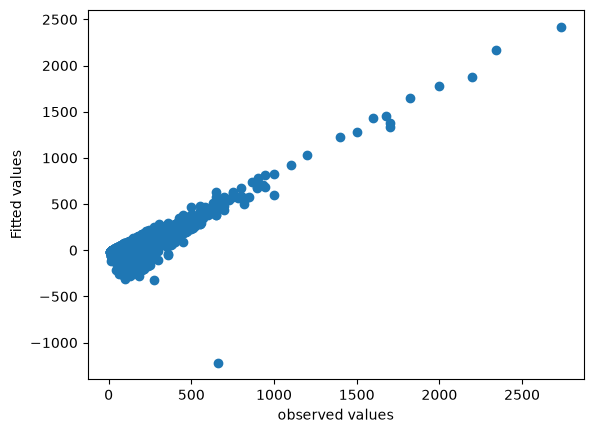

In [58]:
plt.scatter(y_test,test_res)
plt.xlabel("observed values")
plt.ylabel("Fitted values")
plt.show()

# 2.Normality of errors

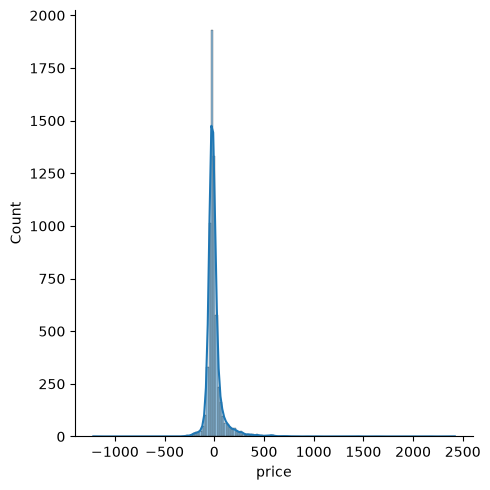

In [60]:
sns.displot(test_res,kde=True)

#plt.hist(test_res)
plt.show()

# 2.Normality of errors

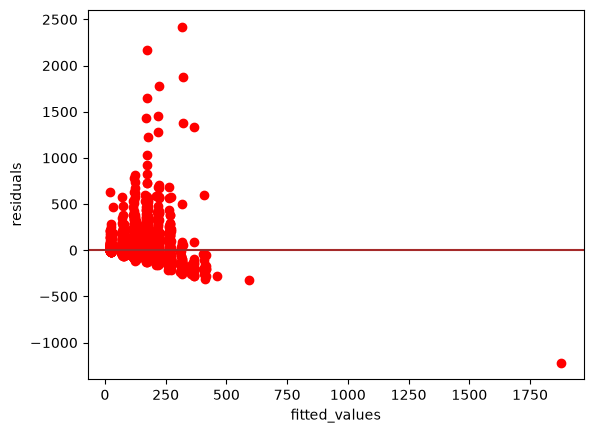

In [62]:
plt.scatter(test_predictions,test_res,c="r")
plt.axhline(y=0,color='brown')
plt.xlabel("fitted_values")
plt.ylabel("residuals")
plt.show()

## save a model

In [72]:
import joblib
joblib.dump(model,'house_model.joblib')

['house_model.joblib']

## Load a model

In [71]:
from joblib import load
loaded_model=load('sales_model.joblib')


In [70]:
loaded_model.predict([[200000,300000,400000]])

array([67070.93317936])

# Polynomial Regression

In [79]:
X=df1[["bath","balcony"]]
y=df1['price']

In [80]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [82]:
from sklearn.preprocessing import PolynomialFeatures
Polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
X_train=pd.DataFrame(Polynomial_converter.fit_transform(X_train))          ##preprocessing
X_test=pd.DataFrame(Polynomial_converter.transform(X_test))

In [84]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 55.8 ,-15.63, -1.13, 3.34, 1.58]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-26.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(5)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[1821.57, 393.53, 137.2 , 45.79, 19.99]"


In [85]:
LinearRegression()

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [86]:
model.intercept_

np.float64(-26.1005665614324)

In [87]:
model.coef_

array([ 55.79637474, -15.63480583,  -1.13433296,   3.34227343,
         1.57725398])

## Predictions

In [90]:
train_predictions=model.predict(X_train)
test_predictions=model.predict(X_test)

## Evalution

In [93]:
model.score(X_train,y_train)

0.22724636791824682

In [95]:
model.score(X_test,y_test)

0.24494907291930923

In [118]:
from sklearn.metrics import mean_absolute_error
print("MAE for test data:",mean_absolute_error(y_test,test_predictions))
print("MAE for train data:",mean_absolute_error(y_train,train_predictions))

MAE for test data: 50.67648825283908
MAE for train data: 49.56628429429268


In [119]:
from sklearn.metrics import mean_squared_error
print("MSE for test data:",mean_squared_error(y_test,test_predictions))
print("MSE for train data:",mean_squared_error(y_train,train_predictions))

MSE for test data: 14691.342117606167
MSE for train data: 12720.39750715269


In [120]:
print("RMSE for test data:",np.sqrt(mean_squared_error(y_test,test_predictions)))
print("RMSE for train data:",np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data: 121.20784676581862
RMSE for train data: 112.7847396909382


In [121]:
from sklearn.metrics import r2_score
print("R2 for test data:",r2_score(y_test,test_predictions))
print("R2 for train data:",r2_score(y_train,train_predictions))

R2 for test data: 0.24494907291930923
R2 for train data: 0.22724636791824682


In [122]:
#preprocessing
from sklearn.preprocessing import PolynomialFeatures
Polynomial_converter=PolynomialFeatures(degree=2,include_bias=False)
x_poly=Polynomial_converter.fit_transform(X)
x_poly=pd.DataFrame((x_poly))                                             ##preprocessing 

#train_test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.3,random_state=42)

#Modelling
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

#prediction
train_predictions=model.predict(X_train)
test_predictions=model.predict(X_test)

#Evaluation
model.score(X_train,y_train)
model.score(X_test,y_test)

0.24494907291930923

## Hyper parameter tuning

In [124]:
train_r2=[]
test_r2=[]


for i in range(1,5):
    from sklearn.preprocessing import PolynomialFeatures
    Polynomial_converter=PolynomialFeatures(degree=i,include_bias=False)
    x_poly=Polynomial_converter.fit_transform(X)
    x_poly=pd.DataFrame((x_poly))

    from sklearn.model_selection import train_test_split
    X_train,X_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.3,random_state=42)

    from sklearn.linear_model import LinearRegression
    model=LinearRegression()
    model.fit(X_train,y_train)

    train_predictions=model.predict(X_train)
    test_predictions=model.predict(X_test)

    train_r2.append(model.score(X_train,y_train))
    test_r2.append(model.score(X_test,y_test))

In [125]:
train_r2

[0.20860505573668187,
 0.22724636791824682,
 0.24882696145808014,
 0.2575367709531874]

In [126]:
test_r2

[0.2171416509230939,
 0.24494907291930923,
 0.25155236550502513,
 0.18545102245625866]

In [127]:
print("RMSE for test data:",np.sqrt(mean_squared_error(y_test,test_predictions)))
print("RMSE for train data:",np.sqrt(mean_squared_error(y_train,train_predictions)))

RMSE for test data: 125.8928933830576
RMSE for train data: 110.55217439829504


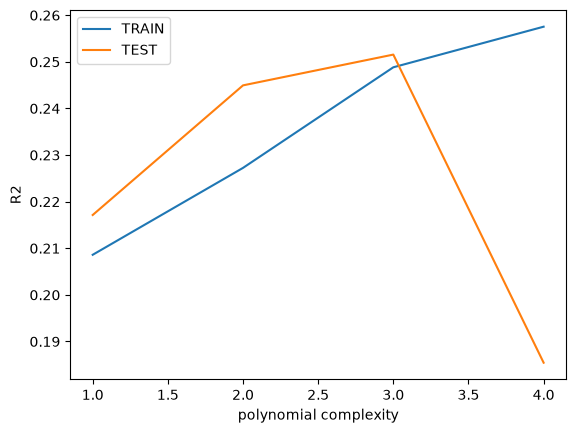

In [128]:
plt.plot(range(1,5),train_r2[:4],label='TRAIN')
plt.plot(range(1,5),test_r2[:4],label='TEST')
plt.xlabel("polynomial complexity")
plt.ylabel("R2")
plt.legend()
plt.show()

In [131]:
final_poly_converter=PolynomialFeatures(degree=3, include_bias=False)
x_poly=final_poly_converter.fit_transform(X) 
# train test splilt 
X_train,X_test,y_train,y_test=train_test_split(x_poly,y,test_size=0.3,random_state=42)
# build the final model
final_model=LinearRegression()
final_model.fit(X_train,y_train)
# prediction
train_pred= final_model.predict(X_train)
test_pred= final_model.predict(X_test) 
# evaluation
print("Train R2", final_model.score(X_train,y_train))
print("Test R2", final_model.score(X_test,y_test)) 

Train R2 0.24882696145808014
Test R2 0.25155236550502524


In [134]:
input_data=[[40000,42000]]
transformed_data=final_poly_converter.transform(input_data)
final_model.predict(transformed_data)

array([-7.05296211e+14])

## save a model

In [136]:
import joblib

In [137]:
joblib.dump(final_poly_converter,'poly_converter.joblib')
joblib.dump(final_model,'house_poly_model.joblib')

['house_poly_model.joblib']

## Load a model

In [139]:
from joblib import load
loaded_poly=load('poly_converter.joblib')
loaded_model=load('house_poly_model.joblib')

## new_prediction

In [142]:
campaign_poly=loaded_poly.transform([[140000,22000]])

loaded_model.predict(campaign_poly)

array([-1.81468729e+15])